In [1]:
# GLOBAL #

import random
import pandas as pd
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from typing import Literal
import os
import string

random.seed(123)
np.random.seed(123)
random_state = 123


# 1. Markov Sampling Validation

- How well can Variable Order Markov (VOM) sampling methods capture the rules used to generate data?
- Under what data conditions do these methods work?
- Does my actual dataset meet these conditions?

In [2]:
# VOM SAMPLING METHODS #

## Helper Functions ##

def read_lines(filename, dir):
    lines = []
    filepath = os.path.join(dir, filename)
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            line = line.replace("<s>", "").replace("</s>", "").strip()
            lines.append(list(line))
    return lines

def collapse_length(seq):
    collapsed = []
    for s in seq:
        if not collapsed or collapsed[-1] != s:
            collapsed.append(s)
    return collapsed

def has_consecutive_repeats(tuple_state):
    for i in range(len(tuple_state) - 1):
        if tuple_state[i] == tuple_state[i + 1]:
            return True
    return False

def unique_indices(seq):
    last_indices = []
    run_char = seq[0]
    for i, s in enumerate(seq[1:], start=1):
        if s != run_char:
            last_indices.append(i - 1)
            run_char = s
    last_indices.append(len(seq) - 1)
    return last_indices

def expand_vector(vec):
    """Maps each position to its corresponding run-ending index."""
    if not vec:
        return []
    result = []
    vec_idx = 0
    for pos in range(vec[-1] + 1):
        while vec_idx < len(vec) - 1 and pos > vec[vec_idx]:
            vec_idx += 1
        result.append(vec[vec_idx])
    return result

def average_log_likelihood(train_probs, test_probs):
    """Weighted average log-likelihood of test transitions under train model."""
    ll = 0.0
    total_weight = 0.0
    for s, nexts in test_probs.items():
        train_context = train_probs.get(s)
        if train_context is None:
            continue                       # context unseen in train — skip
        for s2, p_test in nexts.items():
            p_train = train_context.get(s2)
            if p_train is None or p_train <= 0:
                continue                   # transition unseen in train — skip
            ll += p_test * np.log(p_train)
            total_weight += p_test
    if total_weight == 0:
        return np.nan
    return ll / total_weight


## Main Analysis Functions ##

### k-lagged ###

def normalized_lagged_transitions(states, lines, k, smoother, lag):
    transitions = defaultdict(Counter)
    if k == 0:
        for state in states:
            transitions[()][state] = smoother
        for seq in lines:
            for curr in seq:
                transitions[()][curr] += 1
        total = sum(transitions[()].values())
        return {(): {s: c / total for s, c in transitions[()].items()}}

    for prev in product(states, repeat=k):
        for curr in states:
            transitions[prev][curr] = smoother
    for seq in lines:
        seq_len = len(seq)
        for t in range(k * lag, seq_len):
            prev = tuple(seq[t - lag * i - 1] for i in reversed(range(k)))
            curr = seq[t]
            transitions[prev][curr] += 1

    normalized_transitions = {}
    for cond, counter in transitions.items():
        total = sum(counter.values())
        normalized_transitions[cond] = {s: c / total for s, c in counter.items()}
    return normalized_transitions

def unnormalized_lagged_transitions(lines, k, lag):
    transitions = defaultdict(Counter)
    if k == 0:
        for seq in lines:
            for curr in seq:
                transitions[()][curr] += 1
        return transitions
    for seq in lines:
        seq_len = len(seq)
        for t in range(k * lag, seq_len):
            prev = tuple(seq[t - lag * i - 1] for i in reversed(range(k)))
            curr = seq[t]
            transitions[prev][curr] += 1
    return transitions

### semi-collapsed ###

def normalize_semicol_transitions(states, lines, k, smoother):
    transitions = defaultdict(Counter)
    if k == 0:
        for state in states:
            transitions[()][state] = smoother
        for seq in lines:
            for curr in seq:
                transitions[()][curr] += 1
        total = sum(transitions[()].values())
        return {(): {s: c / total for s, c in transitions[()].items()}}

    for prev in product(states, repeat=k):
        if has_consecutive_repeats(prev):
            continue
        for curr in states:
            transitions[prev][curr] = smoother

    for seq in lines:
        indices = unique_indices(seq)
        expanded_indices = expand_vector(indices)
        for t in range(1, len(seq)):
            collapsed_idx = indices.index(expanded_indices[t - 1])
            if collapsed_idx < k - 1:
                continue
            prev_unique_indices = indices[collapsed_idx - (k - 1):collapsed_idx + 1]
            prev = tuple(seq[i] for i in prev_unique_indices)
            curr = seq[t]
            transitions[prev][curr] += 1

    normalized_transitions = {}
    for cond, counter in transitions.items():
        total = sum(counter.values())
        normalized_transitions[cond] = {s: c / total for s, c in counter.items()}
    return normalized_transitions

def unnormalized_semicol_transitions(lines, k):
    transitions = defaultdict(Counter)
    if k == 0:
        for seq in lines:
            for curr in seq:
                transitions[()][curr] += 1
        return transitions
    for seq in lines:
        indices = unique_indices(seq)
        expanded_indices = expand_vector(indices)
        for t in range(1, len(seq)):
            collapsed_idx = indices.index(expanded_indices[t - 1])
            if collapsed_idx < k - 1:
                continue
            prev_unique_indices = indices[collapsed_idx - (k - 1):collapsed_idx + 1]
            prev = tuple(seq[i] for i in prev_unique_indices)
            curr = seq[t]
            transitions[prev][curr] += 1
    return transitions


### comparative analysis ###

Way  = Literal['lagged', 'semicol']
Fish = Literal['dom', 'sub', 'full']

def find_transitions(species, kmax, smoothers, way: Way,
                     fish: Fish = 'full', lagmax=60, dir=None):
    """Fit k-order transition models on train corpora and evaluate on test.

    Parameters
    ----------
    species  : list  Species codes.
    kmax     : int   Maximum k-order to test.
    smoothers: list  Laplace smoother values.
    way      : str   'semicol' or 'lagged'.
    fish     : str   Which corpus to use: 'dom', 'sub', or 'full'.
    lagmax   : int   Max lag (only used when way='lagged').
    dir      : str   Directory containing corpus text files.

    Returns
    -------
    pd.DataFrame
    """
    states  = ['a','b','c','d','e','f','g','h','j','k']
    results = []

    for specie in species:
        train_lines = read_lines(f"corpus_{specie}_train_{fish}.txt", dir=dir)
        test_lines  = read_lines(f"corpus_{specie}_test_{fish}.txt",  dir=dir)

        for k in range(0, kmax + 1):
            for smoother in smoothers:
                if way == 'lagged':
                    for lag in [1] + list(range(10, lagmax + 1, 10)):
                        train_trans = normalized_lagged_transitions(
                            states, lines=train_lines, k=k,
                            smoother=smoother, lag=lag)
                        test_trans  = unnormalized_lagged_transitions(
                            lines=test_lines, k=k, lag=lag)
                        ll = average_log_likelihood(train_trans, test_trans)
                        results.append({
                            'species': specie, 'k': k,
                            'lag': lag, 'smoother': smoother,
                            'log_likelihood': ll,
                            'num_train_states': len(train_trans),
                            'num_test_states':  len(test_trans),
                        })
                        print(f"Species {specie}, k={k}, lag={lag}, "
                              f"smoother={smoother}: LL={ll:.4f}")
                else:  # semicol
                    train_trans = normalize_semicol_transitions(
                        states, lines=train_lines, k=k, smoother=smoother)
                    test_trans  = unnormalized_semicol_transitions(
                        lines=test_lines, k=k)
                    ll = average_log_likelihood(train_trans, test_trans)
                    results.append({
                        'species': specie, 'k': k,
                        'smoother': smoother,
                        'log_likelihood': ll,
                        'num_train_states': len(train_trans),
                        'num_test_states':  len(test_trans),
                    })
                    print(f"Species {specie}, k={k}, "
                          f"smoother={smoother}: LL={ll:.4f}")

    return pd.DataFrame(results)


### plotting ###

def plot_comparison_grid(species, resultsDF, way: Way):
    """Two-row grid (lag + smoother) for lagged; one-row (smoother) for semicol."""
    n_species = len(species)
    n_rows = 2 if way == 'lagged' else 1
    fig, axes = plt.subplots(n_rows, n_species,
                              figsize=(6 * n_species, 5 * n_rows),
                              sharey='row', squeeze=False)

    k_values = sorted(resultsDF['k'].unique())
    colors   = plt.cm.Accent(np.linspace(0, 1, len(k_values)))

    for i, specie in enumerate(species):
        speciesDF = resultsDF[resultsDF['species'] == specie]
        print(f"\nSpecies: {specie}")

        # --- Row 0: lag (lagged only) ---
        if way == 'lagged':
            ax_lag = axes[0, i]
            for k_idx, k in enumerate(k_values):
                single_k = speciesDF[speciesDF['k'] == k]
                if single_k.empty:
                    continue
                by_lag = (single_k
                          .groupby('lag')
                          .apply(lambda x: x.nlargest(1, 'log_likelihood'),
                                 include_groups=False)
                          .reset_index())
                ax_lag.plot(by_lag['lag'], by_lag['log_likelihood'],
                            'o--', color=colors[k_idx], linewidth=2,
                            markersize=6, label=f'k={k}')
            ax_lag.set_title(f'{specie} — Varying Lag (best smoother)')
            ax_lag.set_xlabel('Lag')
            ax_lag.set_ylabel('Log Likelihood')
            ax_lag.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax_lag.grid(True, alpha=0.3)

        # --- Row (last): smoother ---
        ax_sm = axes[-1, i]
        for k_idx, k in enumerate(k_values):
            single_k = speciesDF[speciesDF['k'] == k]
            if single_k.empty:
                continue
            # For lagged: optimise over lag; for semicol: no lag column
            group_col = 'lag' if way == 'lagged' else 'smoother'
            if way == 'lagged':
                by_smoother = (single_k
                               .groupby('smoother')
                               .apply(lambda x: x.nlargest(1, 'log_likelihood'),
                                      include_groups=False)
                               .reset_index())
            else:
                by_smoother = (single_k
                               .groupby('smoother')['log_likelihood']
                               .max()
                               .reset_index())
            ax_sm.plot(by_smoother['smoother'], by_smoother['log_likelihood'],
                       'o--', color=colors[k_idx], linewidth=2,
                       markersize=6, label=f'k={k}')
        ax_sm.set_title(f'{specie} — Varying Smoother (best lag)')
        ax_sm.set_xlabel('Smoother')
        ax_sm.set_ylabel('Log Likelihood')
        ax_sm.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax_sm.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_best_k_comparison(species, semicol_df, lagged_df):
    """Bar chart comparing best LL per k for semicol vs lagged, one panel per species.

    Parameters
    ----------
    species    : list  Species codes.
    semicol_df : DataFrame  Output of find_transitions(..., way='semicol').
    lagged_df  : DataFrame  Output of find_transitions(..., way='lagged').
    """
    n_species = len(species)

    # k values present in each method (may differ)
    k_semicol = sorted(semicol_df['k'].unique())
    k_lagged  = sorted(lagged_df['k'].unique())
    k_all     = sorted(set(k_semicol) | set(k_lagged))

    width = 0.35
    x     = np.arange(len(k_all))

    fig, axes = plt.subplots(1, n_species,
                              figsize=(6 * n_species, 5),
                              sharey=True)
    if n_species == 1:
        axes = [axes]

    for i, specie in enumerate(species):
        ax = axes[i]

        sc_data = semicol_df[semicol_df['species'] == specie]
        lg_data = lagged_df[lagged_df['species']  == specie]

        best_semicol = []
        best_lagged  = []
        for k in k_all:
            sc_k = sc_data[sc_data['k'] == k]
            lg_k = lg_data[lg_data['k'] == k]
            best_semicol.append(sc_k['log_likelihood'].max() if not sc_k.empty else np.nan)
            best_lagged.append( lg_k['log_likelihood'].max() if not lg_k.empty else np.nan)

        bars_sc = ax.bar(x - width / 2, best_semicol, width,
                         label='Collapsed Context', color='#ecad08', alpha=0.85)
        bars_lg = ax.bar(x + width / 2, best_lagged,  width,
                         label='Lagged Context',  color='#8069b7', alpha=0.85)

        for bars, values in [(bars_sc, best_semicol), (bars_lg, best_lagged)]:
            for bar, value in zip(bars, values):
                if not np.isnan(value):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.003,
                            f'{value:.3f}', ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('Markov Order (k)')
        ax.set_ylabel('Best Log Likelihood')
        ax.set_title(f'Species: {specie}')
        ax.set_xticks(x)
        ax.set_xticklabels(k_all)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        print(f"\n=== {specie} — Best LL per k ===")
        print(f"  {'k':<4} {'semicol':>10} {'lagged':>10}")
        for k, sc, lg in zip(k_all, best_semicol, best_lagged):
            sc_str = f'{sc:.4f}' if not np.isnan(sc) else '     —'
            lg_str = f'{lg:.4f}' if not np.isnan(lg) else '     —'
            print(f"  {k:<4} {sc_str:>10} {lg_str:>10}")

    plt.tight_layout()
    plt.show()


In [3]:
# SIMULATION #

## Helper Functions ##

### entropy ###

def entropy(prob_dist):
    """Shannon entropy of a probability distribution."""
    probs = np.array(list(prob_dist.values()))
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

def nonselfEntropy(prob_dist, context):
    """Entropy excluding the self-transition (last state in context)."""
    if len(context) == 0:
        return entropy(prob_dist)
    last_state = context[-1]
    non_self_dist = {s: p for s, p in prob_dist.items() if s != last_state}
    if not non_self_dist:
        return 0.0
    total = sum(non_self_dist.values())
    if total == 0:
        return 0.0
    normalized = {s: p / total for s, p in non_self_dist.items()}
    return entropy(normalized)

def nonselfMeanNormEntropy(transitions_dict, num_states=10):
    """Mean normalised non-self entropy across all contexts in a transition matrix."""
    entropies = []
    for context, prob_dist in transitions_dict.items():
        if not prob_dist:
            continue
        h = nonselfEntropy(prob_dist, context)
        max_entropy = np.log(num_states - 1) if len(context) > 0 else np.log(num_states)
        normalized_entropy = h / max_entropy if max_entropy > 0 else 0.0
        entropies.append(normalized_entropy)
    return np.mean(entropies) if entropies else np.nan


### synthetic dataset generation ###

def sampleFromDict(probs):
    states = list(probs.keys())
    weights = list(probs.values())
    return random.choices(states, weights=weights, k=1)[0]

def generatePair(length, states, wTrans, bTrans, k, rt, temp):
    """Generate one (dom, sub) sequence pair."""
    domseq = random.choices(states, k=k) if k > 0 else []
    subseq = random.choices(states, k=k) if k > 0 else []

    for t in range(k, length):
        # dom: only wTrans
        prev_dom = tuple(domseq[t - k:t])
        domseq.append(sampleFromDict(wTrans[prev_dom]))

        # sub: wTrans weighted by bTrans when enough history
        prev_sub = tuple(subseq[t - k:t])
        if t < rt or rt == 0:
            probs = wTrans[prev_sub]
        else:
            prev_dom_rt = domseq[t - rt]
            unnorm = {
                curr: wTrans[prev_sub][curr] * (bTrans[curr][prev_dom_rt] ** temp)
                for curr in states
            }
            Z = sum(unnorm.values())
            probs = {c: p / Z for c, p in unnorm.items()}
        subseq.append(sampleFromDict(probs))

    return domseq, subseq

def generateAndSaveCorpus(k, rt, n_pairs, temp, alpha,
                           wTrans, bTrans,
                           seqlength=500,
                           states=['a','b','c','d','e','f','g','h','j','k']):
    """Generate n_pairs sequences and split into train/test.
    Returns a dict with sequence lists and metadata (no files written)."""
    pairs = [
        generatePair(length=seqlength, states=states,
                     wTrans=wTrans, bTrans=bTrans, k=k, rt=rt, temp=temp)
        for _ in range(n_pairs)
    ]
    train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

    def pairs_to_seqs(pair_list):
        dom_seqs, sub_seqs = [], []
        for dom, sub in pair_list:
            dom_seqs.append(list(dom))
            sub_seqs.append(list(sub))
        return dom_seqs, sub_seqs

    train_dom, train_sub = pairs_to_seqs(train_pairs)
    test_dom,  test_sub  = pairs_to_seqs(test_pairs)
    mean_entropy = nonselfMeanNormEntropy(wTrans, len(states))

    return {
        'train_dom': train_dom, 'train_sub': train_sub,
        'test_dom':  test_dom,  'test_sub':  test_sub,
        'params': {'k': k, 'rt': rt, 'n_pairs': n_pairs, 'temp': temp, 'alpha': alpha},
        'mean_entropy': mean_entropy,
    }

def analyze_corpus(corpus_data, kmax, smoothers, lagmax, states,
                   way='semicol'):
    """Fit k-order models (lagged or semicol) on train sequences and score on test.

    Parameters
    ----------
    corpus_data : dict  Output of generateAndSaveCorpus.
    kmax        : int   Maximum order to test.
    smoothers   : list  Laplace-style smoother values.
    lagmax      : int   Maximum lag (only used when way='lagged').
    states      : list  Alphabet.
    way         : str   'semicol' or 'lagged'.

    Returns
    -------
    pd.DataFrame with one row per (k, smoother[, lag]) combination.
    """
    train_lines = corpus_data['train_dom']
    test_lines  = corpus_data['test_dom']
    results = []

    for k in range(0, kmax + 1):
        for smoother in smoothers:
            if way == 'lagged':
                for lag in [1] + list(range(10, lagmax + 1, 10)):
                    train_trans = normalized_lagged_transitions(
                        states, lines=train_lines, k=k, smoother=smoother, lag=lag)
                    test_trans  = unnormalized_lagged_transitions(
                        lines=test_lines, k=k, lag=lag)
                    ll = average_log_likelihood(train_trans, test_trans)
                    results.append({'k': k, 'smoother': smoother, 'lag': lag,
                                    'log_likelihood': ll})
            else:  # semicol
                train_trans = normalize_semicol_transitions(
                    states, lines=train_lines, k=k, smoother=smoother)
                test_trans  = unnormalized_semicol_transitions(
                    lines=test_lines, k=k)
                ll = average_log_likelihood(train_trans, test_trans)
                results.append({'k': k, 'smoother': smoother,
                                'log_likelihood': ll})

    return pd.DataFrame(results)


### simulation runners ###

def runOnce(alpha_values, fixed_params,
            kmax=5, smoothers=[0.01], lagmax=60,
            states=['a','b','c','d','e','f','g','h','j','k'],
            dur_prob=0.95, seqlength=500,
            true_k_values=[0, 1, 2, 3, 4], rt=5,
            way='semicol'):
    """Run one sweep over alpha × true_k combinations.

    Returns
    -------
    all_results  : dict  (alpha, true_k) -> results_df
    entropy_map  : dict  (alpha, true_k) -> mean_entropy
    """
    all_results, entropy_map = {}, {}
    bTrans_cache, wTrans_cache = {}, {}
    total_runs = len(alpha_values) * len(true_k_values)
    current_run = 0

    for alpha in alpha_values:
        for true_k in true_k_values:
            current_run += 1
            print(f"  Run {current_run}/{total_runs}: alpha={alpha}, true_k={true_k}")

            params  = {**fixed_params, 'alpha': alpha}
            temp    = params['temperature']
            n_pairs = params['n_pairs']

            # bTrans: shared per alpha
            if alpha not in bTrans_cache:
                bTrans = defaultdict(Counter)
                for prev in states:
                    weights = np.random.dirichlet([1] * len(states))
                    for curr, w in zip(states, weights):
                        bTrans[curr][prev] = w
                bTrans_cache[alpha] = bTrans
            else:
                bTrans = bTrans_cache[alpha]

            # wTrans: one per (alpha, true_k)
            cache_key = (alpha, true_k)
            if cache_key not in wTrans_cache:
                wTrans = defaultdict(Counter)
                for prev in product(states, repeat=true_k):
                    if true_k == 0:
                        dirichlet_sample = np.random.dirichlet([alpha] * len(states))
                        for s, p in zip(states, dirichlet_sample):
                            wTrans[prev][s] = p
                    else:
                        last_state = prev[-1]
                        other_states = [s for s in states if s != last_state]
                        dirichlet_sample = np.random.dirichlet(
                            [alpha] * len(other_states)) * (1.0 - dur_prob)
                        wTrans[prev][last_state] = dur_prob
                        for s, p in zip(other_states, dirichlet_sample):
                            wTrans[prev][s] = p
                wTrans_cache[cache_key] = wTrans
            else:
                wTrans = wTrans_cache[cache_key]

            corpus_data = generateAndSaveCorpus(
                k=true_k, rt=rt, n_pairs=n_pairs, temp=temp, alpha=alpha,
                seqlength=seqlength, states=states,
                wTrans=wTrans, bTrans=bTrans)

            results_df = analyze_corpus(
                corpus_data, kmax=kmax, smoothers=smoothers,
                lagmax=lagmax, states=states, way=way)

            all_results[cache_key]  = results_df
            entropy_map[cache_key]  = corpus_data['mean_entropy']

            if not results_df.empty:
                best_idx = results_df['log_likelihood'].idxmax()
                best_k   = results_df.loc[best_idx, 'k']
                best_ll  = results_df.loc[best_idx, 'log_likelihood']
                print(f"    Best detected k={best_k} (LL={best_ll:.4f}), "
                      f"entropy={corpus_data['mean_entropy']:.4f}")

    return all_results, entropy_map


def repeated_sims(param_values, fixed_params,
                  kmax=5, smoothers=[0.01], lagmax=60,
                  n_simulations=20, dur_prob=0.95,
                  seqlength=500, true_k_values=None, rt=5,
                  way='semicol'):
    """Run repeated_sims simulations and return a flat DataFrame of outcomes.

    Parameters
    ----------
    param_values    : list  alpha values to sweep.
    fixed_params    : dict  Must contain 'n_pairs', 'temperature'.
    way             : str   'semicol' or 'lagged' — detection method to use.
    """
    if true_k_values is None:
        true_k_values = [0, 1, 2, 3, 4]

    rows = []
    for i in range(n_simulations):
        print(f"\n{'='*50}")
        print(f"Simulation {i+1}/{n_simulations}  [way={way}]")
        print(f"{'='*50}")
        all_results, entropy_map = runOnce(
            param_values, fixed_params,
            kmax=kmax, smoothers=smoothers, lagmax=lagmax,
            dur_prob=dur_prob, seqlength=seqlength,
            true_k_values=true_k_values, rt=rt, way=way)

        for (alpha, true_k), df in all_results.items():
            if df is None or df.empty:
                continue
            best_idx = df['log_likelihood'].idxmax()
            best_k   = df.loc[best_idx, 'k']
            best_ll  = df.loc[best_idx, 'log_likelihood']
            rows.append({
                'sim':      i,
                'alpha':    alpha,
                'n_pairs':  fixed_params['n_pairs'],
                'true_k':   true_k,
                'best_k':   best_k,
                'best_ll':  best_ll,
                'correct':  int(best_k == true_k),
                'entropy':  entropy_map.get((alpha, true_k), np.nan),
                'way':      way,
            })

    return pd.DataFrame(rows)


def repeated_sims_vary_n(n_pairs_values, fixed_params_base,
                          alpha_values,
                          kmax=5, smoothers=[0.01], lagmax=60,
                          n_simulations=20, dur_prob=0.95,
                          seqlength=500, true_k_values=None, rt=5,
                          way='semicol'):
    """Run repeated_sims for each n_pairs value.

    Returns a combined DataFrame with an 'n_pairs' column.
    """
    if true_k_values is None:
        true_k_values = [0, 1, 2, 3, 4]

    all_dfs = []
    for n_pairs in n_pairs_values:
        print(f"\n{'#'*60}")
        print(f"n_pairs = {n_pairs}  [way={way}]")
        print(f"{'#'*60}")
        fixed_params = {**fixed_params_base, 'n_pairs': n_pairs}
        df = repeated_sims(
            alpha_values, fixed_params,
            kmax=kmax, smoothers=smoothers, lagmax=lagmax,
            n_simulations=n_simulations, dur_prob=dur_prob,
            seqlength=seqlength, true_k_values=true_k_values,
            rt=rt, way=way)
        # n_pairs already written per-row by repeated_sims
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index=True)


### plots ###

def plot_detection_rate_by_entropy(rec_df, true_k_values=None,
                                   n_entropy_bins=8, way_label=''):
    """Two-panel plot: overall and per-k detection rate vs mean normalised entropy.

    Parameters
    ----------
    rec_df         : DataFrame  Output of repeated_sims (or repeated_sims_vary_n).
    true_k_values  : list       Which true k values to show (default: all in df).
    n_entropy_bins : int
    way_label      : str        Added to plot titles for clarity.
    """
    if true_k_values is None:
        true_k_values = sorted(rec_df['true_k'].unique())

    rec_df = rec_df[rec_df['true_k'].isin(true_k_values)].copy()

    # Aggregate: mean correct & entropy per (alpha, true_k) across sims
    agg = rec_df.groupby(['alpha', 'true_k']).agg(
        pct_correct=('correct', lambda x: x.mean() * 100),
        mean_entropy=('entropy', 'mean'),
    ).reset_index()

    agg['entropy_bin'] = pd.cut(agg['mean_entropy'], bins=n_entropy_bins)
    agg['bin_mid']     = agg['entropy_bin'].apply(lambda x: x.mid)

    # Overall (exclude k=0 which can be trivially correct)
    overall = (agg[agg['true_k'] != 0]
               .groupby('entropy_bin')
               .agg(pct_correct=('pct_correct', 'mean'),
                    bin_mid=('bin_mid', 'first'))
               .reset_index().dropna())

    chance = 100 / (max(true_k_values) + 1)
    title_suffix = f' — {way_label}' if way_label else ''
    colors = plt.cm.viridis(np.linspace(0, 1, len(true_k_values)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overall
    ax = axes[0]
    ax.plot(overall['bin_mid'], overall['pct_correct'], 'ko-', linewidth=2, markersize=7)
    ax.axhline(chance, color='gray', linestyle='--', alpha=0.7,
               label=f'Chance ({chance:.0f}%)')
    ax.set_xlabel('Mean Normalized Entropy', fontsize=12)
    ax.set_ylabel('% Correct k Detection', fontsize=12)
    ax.set_title(f'Overall Detection Rate vs Entropy{title_suffix}', fontsize=13)
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: per-k
    ax2 = axes[1]
    for idx, tk in enumerate(true_k_values):
        sub = agg[agg['true_k'] == tk].sort_values('mean_entropy')
        ax2.plot(sub['mean_entropy'], sub['pct_correct'], 'o-',
                 color=colors[idx], linewidth=2, markersize=7, label=f'k={tk}')
    ax2.axhline(chance, color='gray', linestyle='--', alpha=0.7)
    ax2.set_xlabel('Mean Normalised Entropy', fontsize=12)
    ax2.set_ylabel('% Correct k Detection', fontsize=12)
    ax2.set_title(f'Per-k Detection Rate vs Entropy{title_suffix}', fontsize=13)
    ax2.set_ylim(0, 105)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return agg, fig


def plot_detection_rate_by_n(rec_df, true_k_values=None, way_label=''):
    """Two-panel plot: overall and per-k detection rate vs dataset size (n_pairs).

    Parameters
    ----------
    rec_df        : DataFrame  Output of repeated_sims_vary_n.
    true_k_values : list       Which true k values to include (default: all).
    way_label     : str        Added to plot titles.
    """
    if true_k_values is None:
        true_k_values = sorted(rec_df['true_k'].unique())

    rec_df = rec_df[rec_df['true_k'].isin(true_k_values)].copy()
    n_pairs_values = sorted(rec_df['n_pairs'].unique())

    # Aggregate: mean correct per (n_pairs, true_k) across sims
    agg = rec_df.groupby(['n_pairs', 'true_k']).agg(
        pct_correct=('correct', lambda x: x.mean() * 100),
    ).reset_index()

    # Overall (exclude k=0)
    overall = (agg[agg['true_k'] != 0]
               .groupby('n_pairs')
               .agg(pct_correct=('pct_correct', 'mean'))
               .reset_index())

    chance = 100 / (max(true_k_values) + 1)
    title_suffix = f' — {way_label}' if way_label else ''
    colors = plt.cm.viridis(np.linspace(0, 1, len(true_k_values)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overall
    ax = axes[0]
    ax.plot(overall['n_pairs'], overall['pct_correct'], 'ko-', linewidth=2, markersize=7)
    ax.axhline(chance, color='gray', linestyle='--', alpha=0.7,
               label=f'Chance ({chance:.0f}%)')
    ax.set_xlabel('n_pairs (dataset size)', fontsize=12)
    ax.set_ylabel('% Correct k Detection', fontsize=12)
    ax.set_title(f'Overall Detection Rate vs Dataset Size{title_suffix}', fontsize=13)
    ax.set_ylim(0, 105)
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: per-k
    ax2 = axes[1]
    for idx, tk in enumerate(true_k_values):
        sub = agg[agg['true_k'] == tk].sort_values('n_pairs')
        ax2.plot(sub['n_pairs'], sub['pct_correct'], 'o-',
                 color=colors[idx], linewidth=2, markersize=7, label=f'k={tk}')
    ax2.axhline(chance, color='gray', linestyle='--', alpha=0.7)
    ax2.set_xlabel('n_pairs (dataset size)', fontsize=12)
    ax2.set_ylabel('% Correct k Detection', fontsize=12)
    ax2.set_title(f'Per-k Detection Rate vs Dataset Size{title_suffix}', fontsize=13)
    ax2.set_ylim(0, 105)
    ax2.set_xscale('log')
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return agg, fig


def plot_method_comparison(rec_semicol, rec_lagged,
                           true_k_values=None, n_entropy_bins=8):
    """Side-by-side detection-rate-vs-entropy for semicol vs lagged.

    Parameters
    ----------
    rec_semicol : DataFrame  Output of repeated_sims with way='semicol'.
    rec_lagged  : DataFrame  Output of repeated_sims with way='lagged'.
    """
    if true_k_values is None:
        true_k_values = sorted(rec_semicol['true_k'].unique())

    chance = 100 / (max(true_k_values) + 1)
    colors = plt.cm.viridis(np.linspace(0, 1, len(true_k_values)))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, (rec_df, label) in zip(axes, [(rec_semicol, 'Collapsed Context'),
                                           (rec_lagged, 'Lagged Context')]):
        sub_df = rec_df[rec_df['true_k'].isin(true_k_values)].copy()
        agg = sub_df.groupby(['alpha', 'true_k']).agg(
            pct_correct=('correct', lambda x: x.mean() * 100),
            mean_entropy=('entropy', 'mean'),
        ).reset_index()

        for idx, tk in enumerate(true_k_values):
            sub = agg[agg['true_k'] == tk].sort_values('mean_entropy')
            ax.plot(sub['mean_entropy'], sub['pct_correct'], 'o-',
                    color=colors[idx], linewidth=2, markersize=7,
                    label=f'k={tk}')

        ax.axhline(chance, color='gray', linestyle='--', alpha=0.7,
                   label=f'Chance ({chance:.0f}%)')
        ax.set_xlabel('Mean Normalised Entropy', fontsize=12)
        ax.set_ylabel('% Correct k Detection', fontsize=12)
        ax.set_title(f'Detection Rate vs Entropy\n({label})', fontsize=13)
        ax.set_ylim(0, 105)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Collapsed Context vs Lagged Context: k-order Detection Accuracy', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig


# 2. VOM Sampling Comparisons

- what VOM-based sampling method performs the best with my data?

Species bre, k=0, smoother=0.001: LL=-2.3454
Species bre, k=0, smoother=0.01: LL=-2.3454
Species bre, k=0, smoother=0.1: LL=-2.3454
Species bre, k=1, smoother=0.001: LL=-0.1008
Species bre, k=1, smoother=0.01: LL=-0.1008
Species bre, k=1, smoother=0.1: LL=-0.1008
Species bre, k=2, smoother=0.001: LL=-0.1024
Species bre, k=2, smoother=0.01: LL=-0.1024
Species bre, k=2, smoother=0.1: LL=-0.1025
Species bre, k=3, smoother=0.001: LL=-0.1195
Species bre, k=3, smoother=0.01: LL=-0.1167
Species bre, k=3, smoother=0.1: LL=-0.1173
Species bre, k=4, smoother=0.001: LL=-0.2167
Species bre, k=4, smoother=0.01: LL=-0.2114
Species bre, k=4, smoother=0.1: LL=-0.2213
Species bre, k=5, smoother=0.001: LL=-1.3393
Species bre, k=5, smoother=0.01: LL=-1.0502
Species bre, k=5, smoother=0.1: LL=-0.8345
Species mul, k=0, smoother=0.001: LL=-2.2160
Species mul, k=0, smoother=0.01: LL=-2.2160
Species mul, k=0, smoother=0.1: LL=-2.2160
Species mul, k=1, smoother=0.001: LL=-0.1208
Species mul, k=1, smoother=0.01

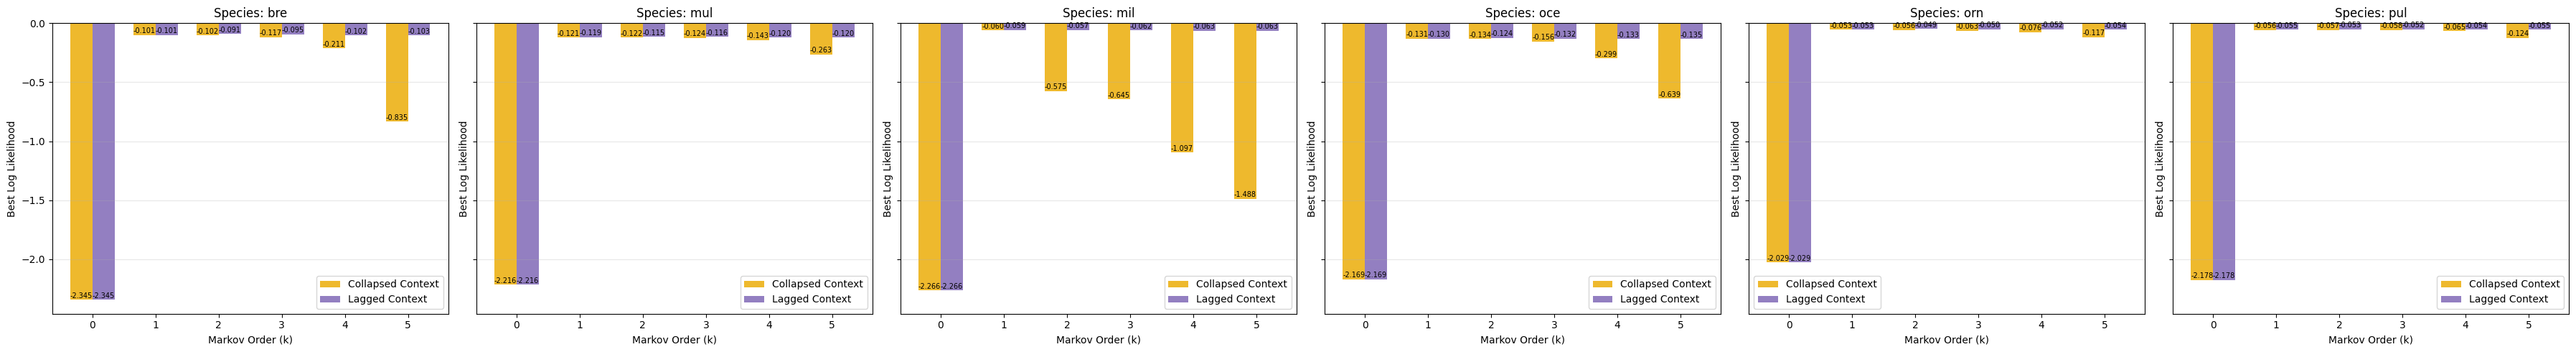


Species: bre

Species: mul

Species: mil

Species: oce

Species: orn

Species: pul


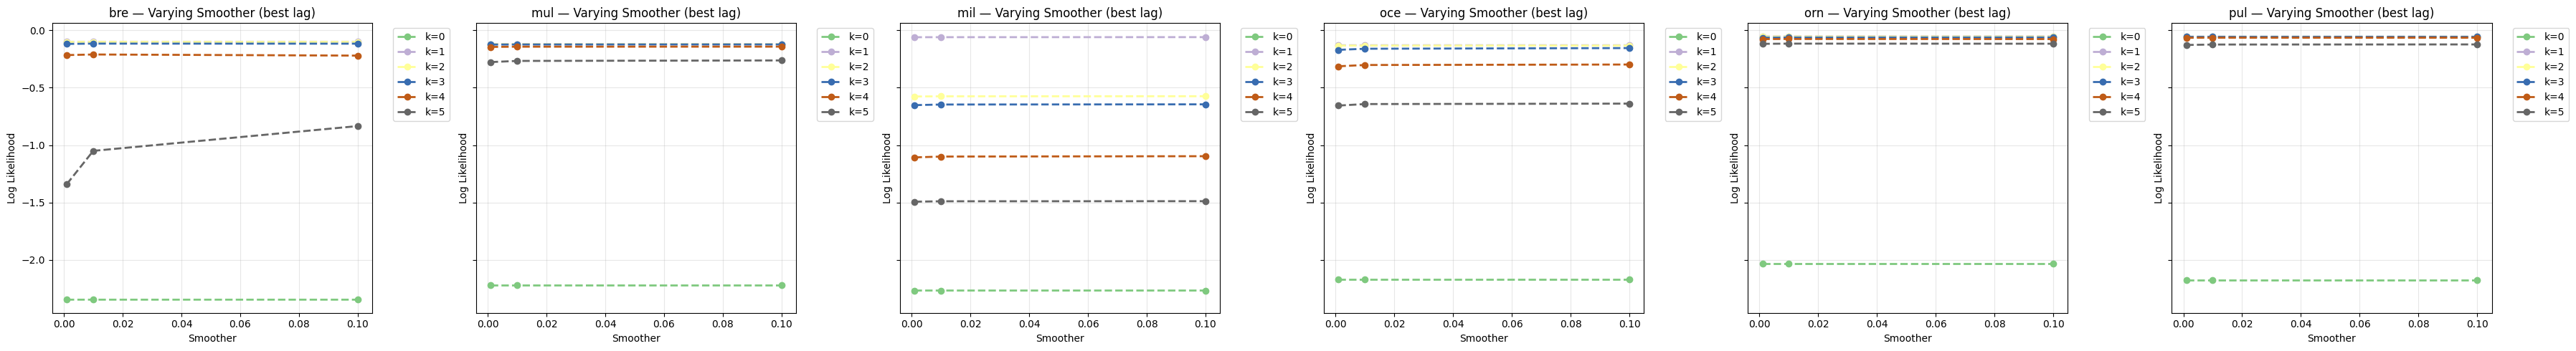


Species: bre

Species: mul

Species: mil

Species: oce

Species: orn

Species: pul


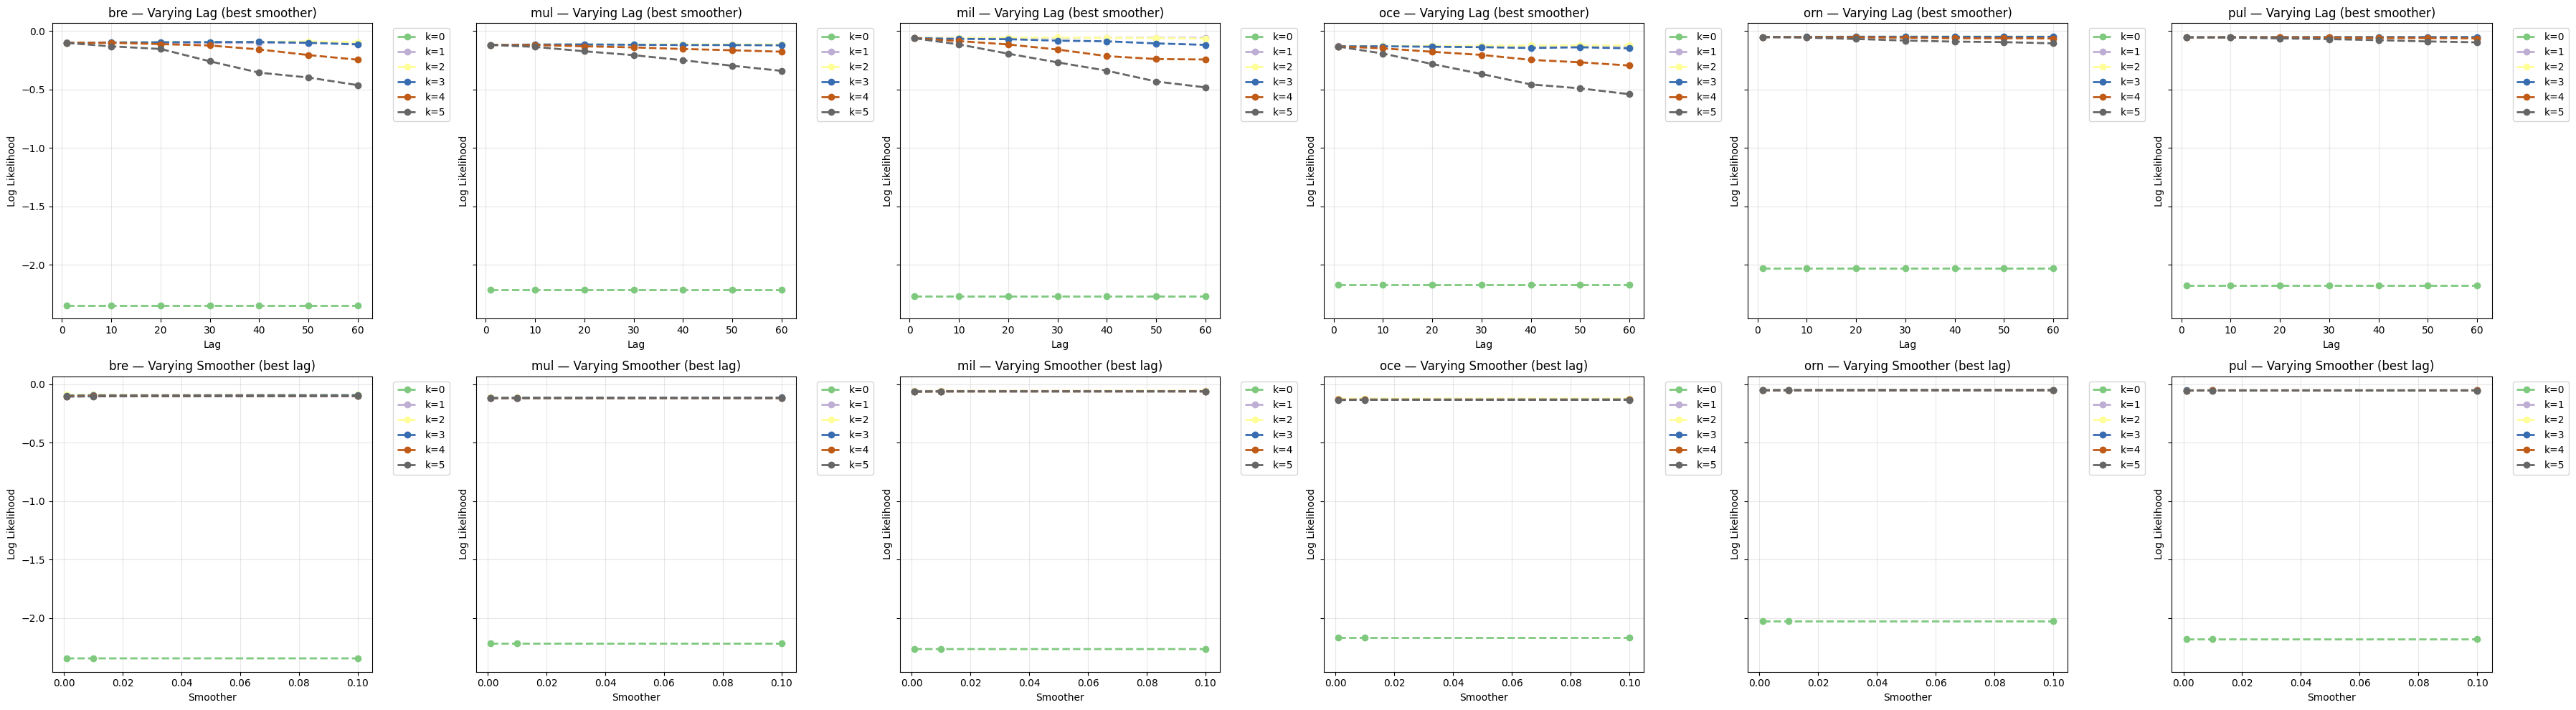

In [18]:
# COMPARATIVE ANALYSIS #

species = ['bre','mul','mil','oce','orn','pul']

# Run semicol analysis (1F only)
results1F_semicol = find_transitions(
    species, kmax=5,
    smoothers=[0.001, 0.01, 0.1],
    way='semicol',
    fish='full',
    dir='species corpora'
)

# Run lagged analysis (1F only)
results1F_lagged = find_transitions(
    species, kmax=5,
    smoothers=[0.001, 0.01, 0.1],
    way='lagged',
    fish='full',
    lagmax=60,
    dir='species corpora'
)

# --- Plots ---

# combined semicol vs lagged best-LL comparison
plot_best_k_comparison(species, results1F_semicol, results1F_lagged)

# detailed hyperparameter grids per method
plot_comparison_grid(species, results1F_semicol, way='semicol')
plot_comparison_grid(species, results1F_lagged, way='lagged')


# 3. Synthetic Evaluation
- under what conditions is the generation strategy consistently recovered?

=== Entropy sweep — semicol ===

Simulation 1/20  [way=semicol]
  Run 1/30: alpha=0.1, true_k=0
    Best detected k=0 (LL=-1.3958), entropy=0.6040
  Run 2/30: alpha=0.1, true_k=1
    Best detected k=1 (LL=-0.2173), entropy=0.2892
  Run 3/30: alpha=0.1, true_k=2
    Best detected k=2 (LL=-0.2527), entropy=0.3752
  Run 4/30: alpha=0.1, true_k=3
    Best detected k=2 (LL=-0.2563), entropy=0.3554
  Run 5/30: alpha=0.1, true_k=4
    Best detected k=2 (LL=-0.2707), entropy=0.3546
  Run 6/30: alpha=0.1, true_k=5
    Best detected k=2 (LL=-0.2949), entropy=0.3546
  Run 7/30: alpha=0.5, true_k=0
    Best detected k=0 (LL=-1.9507), entropy=0.8479
  Run 8/30: alpha=0.5, true_k=1
    Best detected k=1 (LL=-0.2679), entropy=0.7397
  Run 9/30: alpha=0.5, true_k=2
    Best detected k=2 (LL=-0.3055), entropy=0.7461
  Run 10/30: alpha=0.5, true_k=3
    Best detected k=2 (LL=-0.2972), entropy=0.7175
  Run 11/30: alpha=0.5, true_k=4
    Best detected k=2 (LL=-0.3103), entropy=0.7164
  Run 12/30: alpha=0.

C:\Users\anany\AppData\Local\Temp\ipykernel_31976\3155538082.py:338: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('entropy_bin')


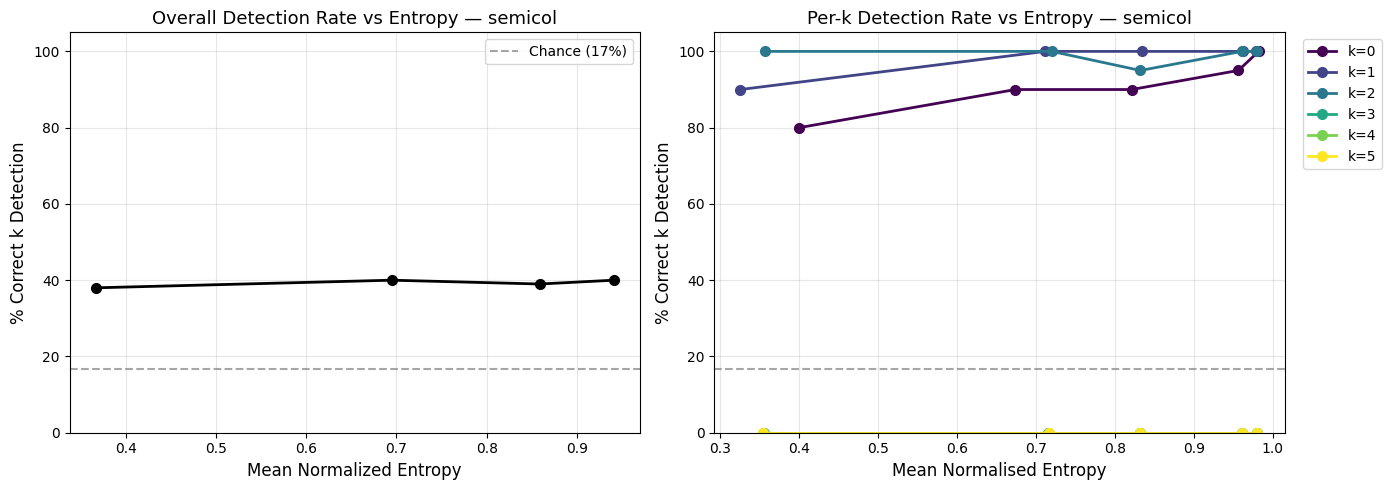

C:\Users\anany\AppData\Local\Temp\ipykernel_31976\3155538082.py:338: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('entropy_bin')


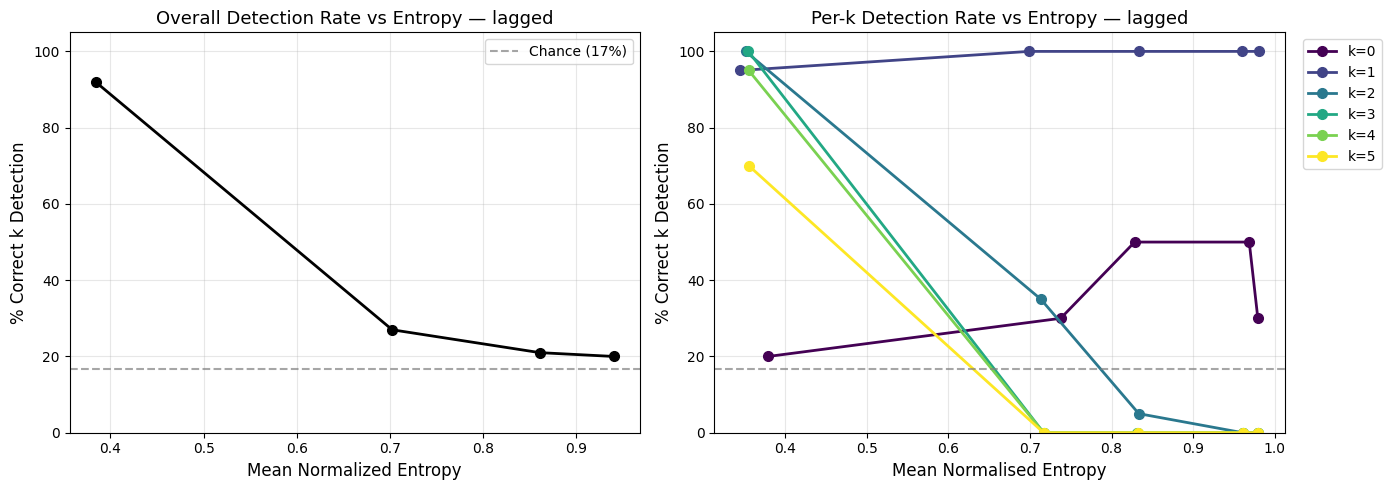

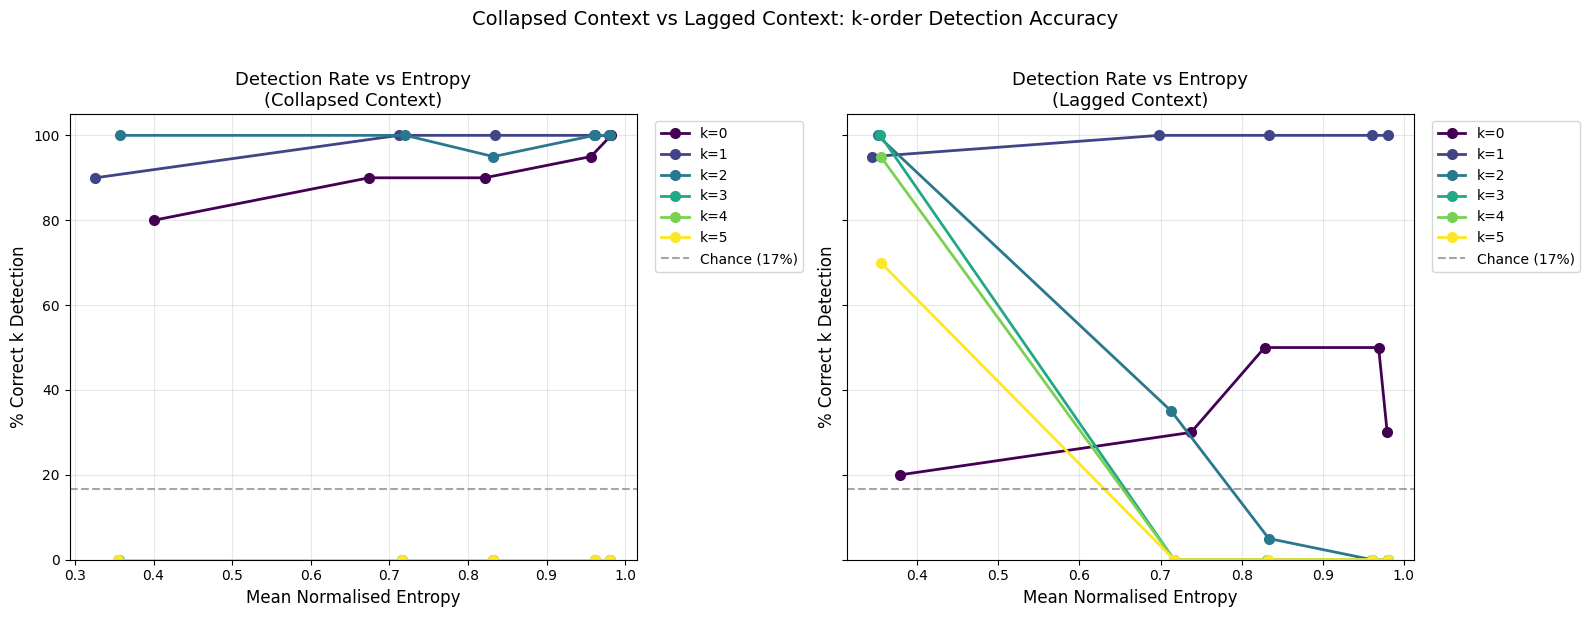

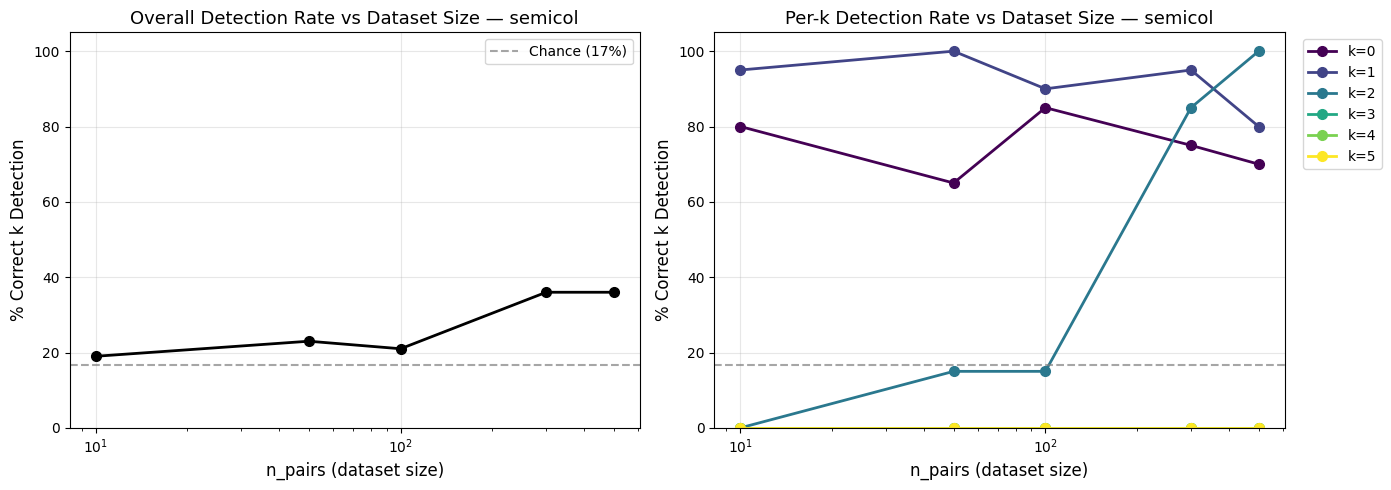

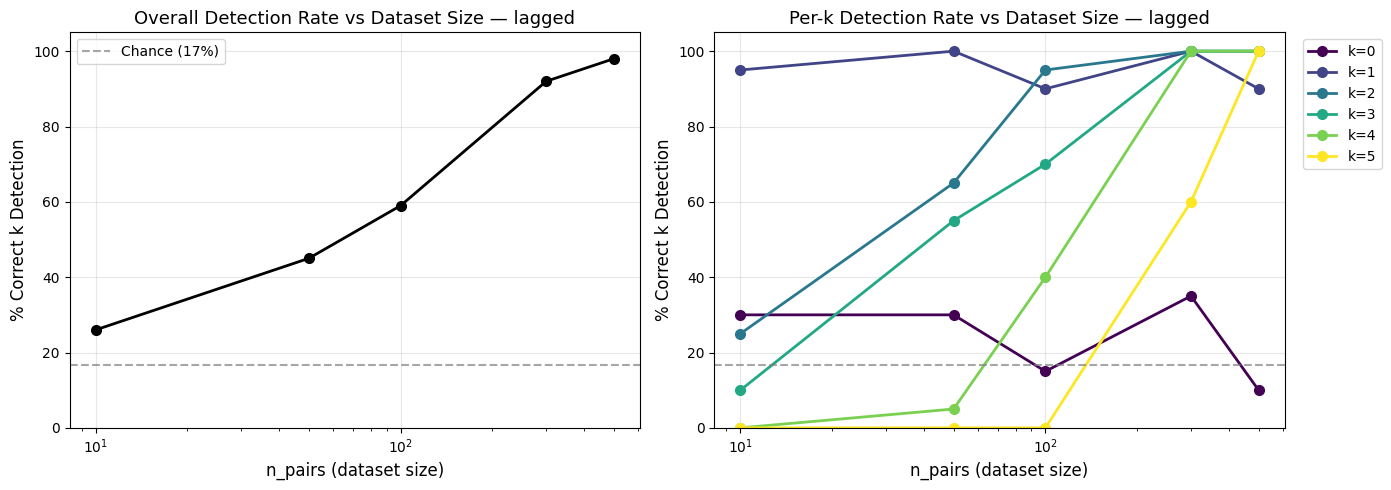

(    n_pairs  true_k  pct_correct
 0        10       0         30.0
 1        10       1         95.0
 2        10       2         25.0
 3        10       3         10.0
 4        10       4          0.0
 5        10       5          0.0
 6        50       0         30.0
 7        50       1        100.0
 8        50       2         65.0
 9        50       3         55.0
 10       50       4          5.0
 11       50       5          0.0
 12      100       0         15.0
 13      100       1         90.0
 14      100       2         95.0
 15      100       3         70.0
 16      100       4         40.0
 17      100       5          0.0
 18      300       0         35.0
 19      300       1        100.0
 20      300       2        100.0
 21      300       3        100.0
 22      300       4        100.0
 23      300       5         60.0
 24      500       0         10.0
 25      500       1         90.0
 26      500       2        100.0
 27      500       3        100.0
 28      500  

In [8]:
# SYNTHETIC EVALUATION #
# Under what conditions is the generation strategy consistently recovered?

# ── Parameters ────────────────────────────────────────────────────────────────

alpha_values   = [0.1, 0.5, 1.0, 5.0, 10.0]   # controls wTrans entropy
n_pairs_values = [10, 50, 100, 300, 500]             # dataset sizes to compare

fixed_params_base = {
    'temperature': 1.0,   # influence of bTrans on subseq, not relevant anymore
    'n_pairs':    300,    # default; overridden in vary-n sweeps
}

true_k_values = [0, 1, 2, 3, 4, 5]
kmax          = 5
smoothers     = [0.01]
n_simulations = 20   # repeated runs per condition

# ── 1. Entropy effect (fixed n_pairs, vary alpha) ─────────────────────────────

print("=== Entropy sweep — semicol ===")
rec_semicol_entropy = repeated_sims(
    alpha_values, fixed_params_base,
    kmax=kmax, smoothers=smoothers,
    n_simulations=n_simulations,
    true_k_values=true_k_values,
    way='semicol'
)

print("\n=== Entropy sweep — lagged ===")
rec_lagged_entropy = repeated_sims(
    alpha_values, fixed_params_base,
    kmax=kmax, smoothers=smoothers,
    n_simulations=n_simulations,
    true_k_values=true_k_values,
    way='lagged'
)

# ── 2. Dataset-size effect (vary n_pairs, fixed alpha=0.1) ────────────────────

print("\n=== n_pairs sweep — semicol ===")
rec_semicol_n = repeated_sims_vary_n(
    n_pairs_values,
    fixed_params_base,
    alpha_values=[0.1],     # fix alpha for clean size comparison
    kmax=kmax, smoothers=smoothers,
    n_simulations=n_simulations,
    true_k_values=true_k_values,
    way='semicol'
)

print("\n=== n_pairs sweep — lagged ===")
rec_lagged_n = repeated_sims_vary_n(
    n_pairs_values,
    fixed_params_base,
    alpha_values=[0.1],
    kmax=kmax, smoothers=smoothers,
    n_simulations=n_simulations,
    true_k_values=true_k_values,
    way='lagged'
)

# ── 3. Plots ──────────────────────────────────────────────────────────────────

# 3a. Detection rate vs entropy — semicol and lagged separately
plot_detection_rate_by_entropy(rec_semicol_entropy,
                                true_k_values=true_k_values,
                                way_label='semicol')
plot_detection_rate_by_entropy(rec_lagged_entropy,
                                true_k_values=true_k_values,
                                way_label='lagged')

# 3b. Detection rate vs entropy — direct method comparison
plot_method_comparison(rec_semicol_entropy, rec_lagged_entropy,
                       true_k_values=true_k_values)

# 3c. Detection rate vs dataset size — semicol and lagged
plot_detection_rate_by_n(rec_semicol_n, true_k_values=true_k_values,
                          way_label='semicol')
plot_detection_rate_by_n(rec_lagged_n, true_k_values=true_k_values,
                          way_label='lagged')


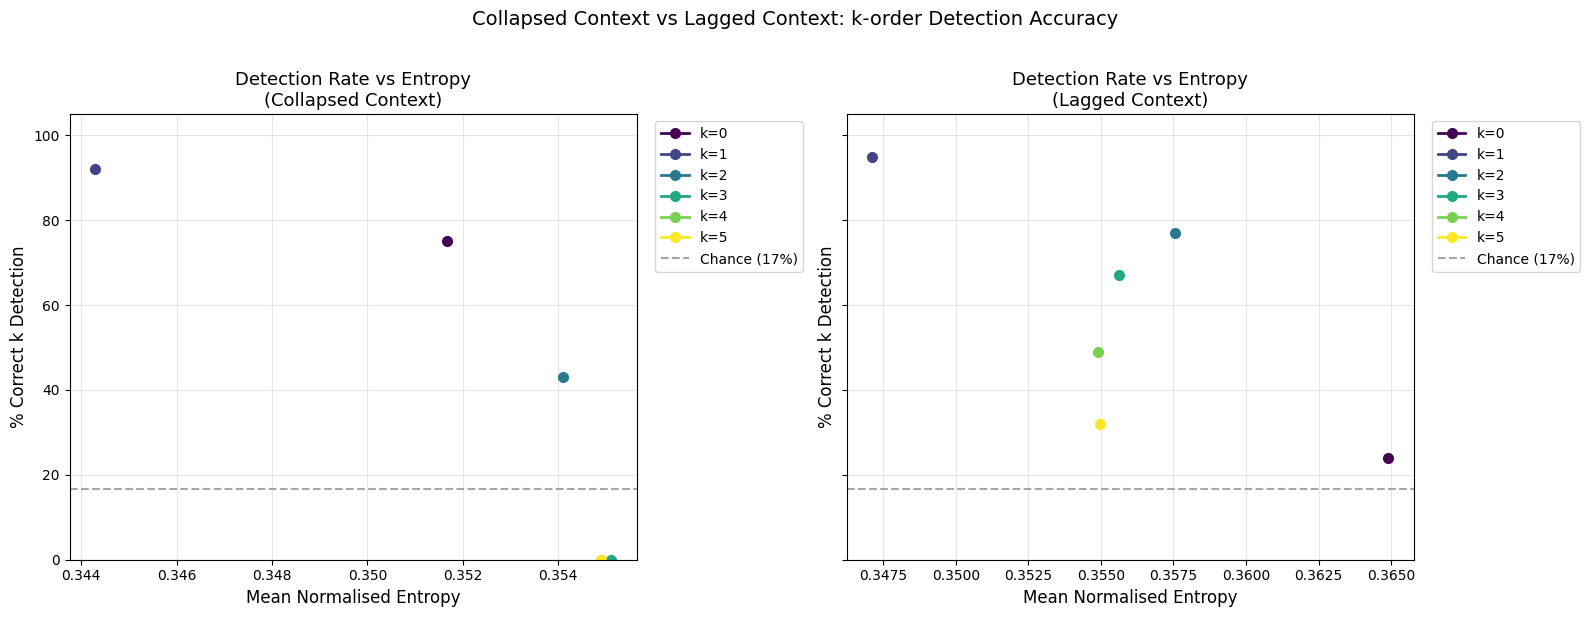

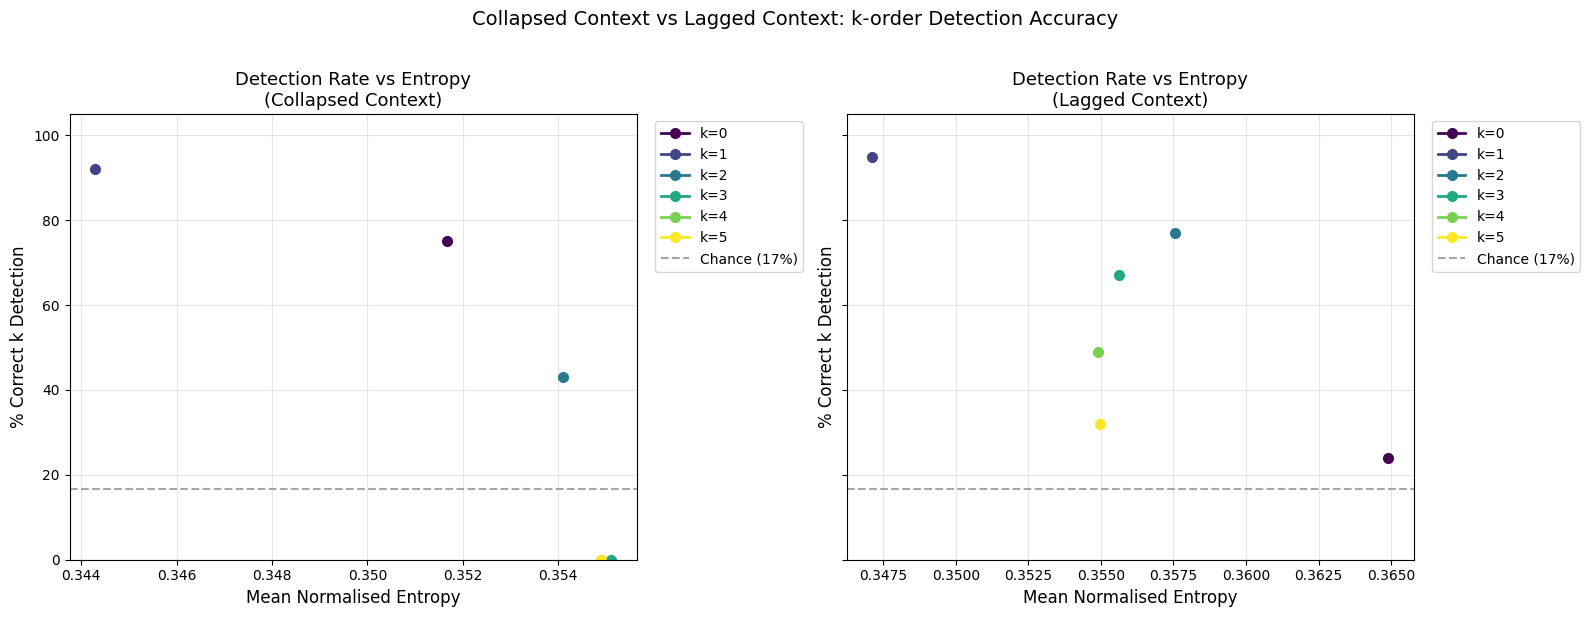

In [9]:
plot_method_comparison(rec_semicol_n, rec_lagged_n,
                       true_k_values=true_k_values)

In [ ]:
# EMPIRICAL ENTROPY TABLE #
# Compute mean normalised non-self entropy of the first-order transition matrix
# for each species, using the full corpus (train + test combined).

corpus_dir = 'species corpora'
states     = ['a','b','c','d','e','f','g','h','j','k']
ks = [0,1,2,3,4,5]

entropy_rows = []

for specie in species:
    for k in ks:
        # Read train and test lines and combine into full corpus
        train_lines = read_lines(f"corpus_{specie}_train_full.txt", dir=corpus_dir)
        test_lines  = read_lines(f"corpus_{specie}_test_full.txt",  dir=corpus_dir)
        all_lines   = train_lines + test_lines

        n_pairs = len(all_lines)

        # Fit first-order (k=1, lag=1) transition matrix with minimal smoothing
        trans = normalized_lagged_transitions(
            states, lines=all_lines, k=k, smoother=1e-6, lag=1
        )

        mean_ent = nonselfMeanNormEntropy(trans, num_states=len(states))
        entropy_rows.append({'species': specie, 'mean_norm_nonself_entropy': round(mean_ent, 4)})
        print(f"{specie}: k = {k}, npairs = {n_pairs}, H = {mean_ent:.4f}")


bre: k = 0, npairs = 180, H = 0.9505
bre: k = 1, npairs = 180, H = 0.4995
bre: k = 2, npairs = 180, H = 0.8035
bre: k = 3, npairs = 180, H = 0.9641
bre: k = 4, npairs = 180, H = 0.9937
bre: k = 5, npairs = 180, H = 0.9991
mul: k = 0, npairs = 778, H = 0.9650
mul: k = 1, npairs = 778, H = 0.5267
mul: k = 2, npairs = 778, H = 0.6347
mul: k = 3, npairs = 778, H = 0.9002
mul: k = 4, npairs = 778, H = 0.9814
mul: k = 5, npairs = 778, H = 0.9969
mil: k = 0, npairs = 78, H = 0.9067
mil: k = 1, npairs = 78, H = 0.4668
mil: k = 2, npairs = 78, H = 0.8871
mil: k = 3, npairs = 78, H = 0.9776
mil: k = 4, npairs = 78, H = 0.9955
mil: k = 5, npairs = 78, H = 0.9992
oce: k = 0, npairs = 164, H = 0.9336
oce: k = 1, npairs = 164, H = 0.5262
oce: k = 2, npairs = 164, H = 0.7728
oce: k = 3, npairs = 164, H = 0.9500
oce: k = 4, npairs = 164, H = 0.9913
oce: k = 5, npairs = 164, H = 0.9987
orn: k = 0, npairs = 478, H = 0.9181
orn: k = 1, npairs = 478, H = 0.5278
orn: k = 2, npairs = 478, H = 0.7063
orn: k 